# 1986 Backpropagation

In 1986, David Rumelhart, Geoffrey Hinton, and Ronald Williams showed how backpropagation could train multilayer neural networks effectively. This made it practical to adjust hidden-layer weights instead of only training a single output perceptron.

## High-Level Ideas

A single perceptron cannot learn XOR because XOR is not linearly separable. To solve it, we use a small multilayer perceptron with two inputs, one hidden layer, and one output.

The topology below has its own `MultilayerPerceptronNeuron` class. That keeps the single-layer `Perceptron` focused on step activation, while each multilayer neuron owns its sigmoid activation behavior so the trainer can calculate gradients with backpropagation.

Backpropagation starts at the output layer, measures how far the prediction is from the desired output, and sends that error backward through the hidden layer. Each neuron then updates its weights and bias according to how much it contributed to the error.

The trainer code mirrors those steps with separate methods: `train_one_example`, `output_layer_deltas`, `hidden_layer_deltas`, and `update_weights_and_biases`.

For this topology, each neuron uses the sigmoid activation:

$$a = \frac{1}{1 + e^{-z}}$$

The output layer delta is:

$$\delta_{output} = (desired\ output - prediction) \times a(1 - a)$$

Each hidden layer delta uses the deltas from the next layer:

$$\delta_{hidden} = \left(\sum w_{next}\delta_{next}\right) \times a(1 - a)$$

## Example: XOR with a Multilayer Perceptron

The code below trains a small multilayer perceptron on the `XOR` truth table and checks that the trained network predicts every case correctly.

In [1]:
import math
import random


# Each neuron owns the parameters and activation operations needed by backpropagation.
class MultilayerPerceptronNeuron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def weighted_sum(self, inputs):
        # The bias acts like an additional learned input that is always on.
        return sum(weight * value for weight, value in zip(self.weights, inputs)) + self.bias

    def activate(self, inputs):
        # Sigmoid maps any weighted sum to a smooth value between 0 and 1.
        return 1 / (1 + math.exp(-self.weighted_sum(inputs)))

    def activation_derivative(self, activation):
        # Reusing the activation avoids evaluating the exponential a second time.
        return activation * (1 - activation)

    def update(self, inputs, delta, learning_rate):
        # The delta assigns this neuron its share of the prediction error.
        self.weights = [
            weight + learning_rate * delta * value
            for weight, value in zip(self.weights, inputs)
        ]
        self.bias += learning_rate * delta


class MultilayerPerceptron:
    def __init__(self, layer_sizes, seed=1):
        if len(layer_sizes) < 2:
            raise ValueError("A multilayer perceptron needs at least an input layer and an output layer.")

        # Seeded random weights break symmetry while keeping the example reproducible.
        random_generator = random.Random(seed)
        self.layers = []

        # Adjacent size pairs describe every fully connected layer.
        for input_count, neuron_count in zip(layer_sizes, layer_sizes[1:]):
            layer = [
                MultilayerPerceptronNeuron(
                    weights=[random_generator.uniform(-1, 1) for _ in range(input_count)],
                    bias=random_generator.uniform(-1, 1),
                )
                for _ in range(neuron_count)
            ]
            self.layers.append(layer)

    def forward(self, inputs):
        # Save every layer's activations because the backward pass needs them.
        activations = [list(inputs)]

        for layer in self.layers:
            current_outputs = [neuron.activate(activations[-1]) for neuron in layer]
            activations.append(current_outputs)

        return activations

    def predict_probability(self, inputs):
        return self.predict_probabilities(inputs)[0]

    def predict(self, inputs):
        return 1 if self.predict_probability(inputs) >= 0.5 else 0

    def predict_probabilities(self, inputs):
        return self.forward(inputs)[-1]

    def predict_class(self, inputs):
        # For multiclass output, the most active output neuron wins.
        probabilities = self.predict_probabilities(inputs)
        return max(range(len(probabilities)), key=probabilities.__getitem__)


class MultilayerPerceptronTrainer:
    def __init__(self, topology, learning_rate=0.5):
        self.topology = topology
        self.learning_rate = learning_rate

    def train(self, training_data, epochs=10000, target_error=0.01):
        # An epoch updates the network once for every training example.
        for _ in range(epochs):
            total_error = 0

            for inputs, desired_output in training_data:
                total_error += self.train_one_example(inputs, desired_output)

            # Stop when the accumulated squared error is sufficiently small.
            if total_error < target_error:
                break

        return self.topology

    def train_one_example(self, inputs, desired_output):
        activations = self.topology.forward(inputs)
        desired_outputs = (
            list(desired_output)
            if isinstance(desired_output, (list, tuple))
            else [desired_output]
        )
        # A scalar target supports XOR; a vector target supports digit classes.
        output_errors = self.output_errors(
            desired_outputs=desired_outputs,
            predictions=activations[-1],
        )
        # Propagate responsibility backward before changing any weights.
        deltas = self.backpropagate_deltas(activations, output_errors)
        self.update_weights_and_biases(activations, deltas)

        return sum(error ** 2 for error in output_errors)

    def output_errors(self, desired_outputs, predictions):
        return [
            desired - prediction
            for desired, prediction in zip(desired_outputs, predictions)
        ]

    def backpropagate_deltas(self, activations, output_errors):
        deltas = [None] * len(self.topology.layers)
        # Output deltas start with the directly observed prediction errors.
        deltas[-1] = self.output_layer_deltas(output_errors, activations[-1])

        # Hidden layers are processed from right to left: the backpropagation step.
        for layer_index in range(len(self.topology.layers) - 2, -1, -1):
            deltas[layer_index] = self.hidden_layer_deltas(
                layer_index,
                activations,
                deltas[layer_index + 1],
            )

        return deltas

    def output_layer_deltas(self, output_errors, output_activations):
        output_layer = self.topology.layers[-1]

        return [
            error * neuron.activation_derivative(activation)
            for error, activation, neuron in zip(
                output_errors,
                output_activations,
                output_layer,
            )
        ]

    def hidden_layer_deltas(self, layer_index, activations, next_layer_deltas):
        current_layer = self.topology.layers[layer_index]
        next_layer = self.topology.layers[layer_index + 1]
        current_activations = activations[layer_index + 1]

        return [
            self.hidden_neuron_delta(
                neuron_index,
                neuron,
                activation,
                next_layer,
                next_layer_deltas,
            )
            for neuron_index, (neuron, activation) in enumerate(
                zip(current_layer, current_activations)
            )
        ]

    def hidden_neuron_delta(self, neuron_index, neuron, activation, next_layer, next_layer_deltas):
        # Weight each downstream delta by the connection leaving this hidden neuron.
        downstream_error = sum(
            next_neuron.weights[neuron_index] * next_layer_deltas[next_index]
            for next_index, next_neuron in enumerate(next_layer)
        )

        return downstream_error * neuron.activation_derivative(activation)

    def update_weights_and_biases(self, activations, deltas):
        # Each weight update uses the activation that entered its connection.
        for layer_index, layer in enumerate(self.topology.layers):
            previous_activations = activations[layer_index]

            for neuron, delta in zip(layer, deltas[layer_index]):
                neuron.update(previous_activations, delta, self.learning_rate)


# XOR is the classic nonlinear test: equal inputs map to 0 and different inputs to 1.
xor_training_data = [
    ((0, 0), 0),
    ((0, 1), 1),
    ((1, 0), 1),
    ((1, 1), 0),
]

xor_gate = MultilayerPerceptron(layer_sizes=[2, 2, 1], seed=1)
MultilayerPerceptronTrainer(xor_gate, learning_rate=0.5).train(xor_training_data)

print("XOR gate")
for values, _ in xor_training_data:
    probability = xor_gate.predict_probability(values)
    print(f"{values} -> {xor_gate.predict(values)} (probability={probability:.3f})")

# Verify all four truth-table rows after training.
for inputs, desired_output in xor_training_data:
    assert xor_gate.predict(inputs) == desired_output

print("\nXOR multilayer perceptron checks passed.")

XOR gate
(0, 0) -> 0 (probability=0.050)
(0, 1) -> 1 (probability=0.957)
(1, 0) -> 1 (probability=0.940)
(1, 1) -> 0 (probability=0.044)

XOR multilayer perceptron checks passed.


## Example: Reading Digits from an Image

Images become neural-network inputs by turning each pixel into a number. This example learns ten small 5-by-7 digit patterns, with a few randomly altered training copies so the network does not see only one perfect image per class. The ten output neurons represent the digits 0 through 9.

After training, the code creates a PNG containing `1986`, loads the PNG back as grayscale pixels, splits it into four known-size cells, and asks the network which output neuron is most active for each cell. This is a deliberately tiny version of optical character recognition (OCR): practical systems also locate text, handle varied fonts and sizes, and train on much larger image collections.

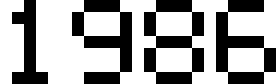

Recognized number: 1986
Winning output activations: [0.989, 0.976, 0.975, 0.974]


In [2]:
from io import BytesIO

from IPython.display import display
from PIL import Image


# '#' represents a dark pixel and '.' a white pixel in each 5-by-7 template.
DIGIT_PATTERNS = {
    0: (".###.", "#...#", "#...#", "#...#", "#...#", "#...#", ".###."),
    1: ("..#..", ".##..", "..#..", "..#..", "..#..", "..#..", ".###."),
    2: (".###.", "#...#", "....#", "...#.", "..#..", ".#...", "#####"),
    3: ("####.", "....#", "....#", ".###.", "....#", "....#", "####."),
    4: ("...#.", "..##.", ".#.#.", "#..#.", "#####", "...#.", "...#."),
    5: ("#####", "#....", "#....", "####.", "....#", "....#", "####."),
    6: (".###.", "#....", "#....", "####.", "#...#", "#...#", ".###."),
    7: ("#####", "....#", "...#.", "..#..", ".#...", ".#...", ".#..."),
    8: (".###.", "#...#", "#...#", ".###.", "#...#", "#...#", ".###."),
    9: (".###.", "#...#", "#...#", ".####", "....#", "....#", ".###."),
}

DIGIT_WIDTH = 5
DIGIT_HEIGHT = 7
DIGIT_SPACING = 1


def pattern_pixels(pattern):
    # Flatten rows into the 35 numeric inputs expected by the network.
    return [1.0 if pixel == "#" else 0.0 for row in pattern for pixel in row]


def one_hot(digit):
    # The correct class is 1 and every competing digit class is 0.
    return [1.0 if candidate == digit else 0.0 for candidate in range(10)]


# A fixed seed makes the deliberately corrupted training copies reproducible.
noise_generator = random.Random(1986)
digit_training_data = []

for digit, pattern in DIGIT_PATTERNS.items():
    clean_pixels = pattern_pixels(pattern)
    digit_training_data.append((clean_pixels, one_hot(digit)))

    # Pixel noise teaches the model something broader than one perfect template.
    for _ in range(4):
        noisy_pixels = [
            1.0 - pixel if noise_generator.random() < 0.04 else pixel
            for pixel in clean_pixels
        ]
        digit_training_data.append((noisy_pixels, one_hot(digit)))

# The topology has 35 pixels, 16 hidden features, and one output per digit.
digit_reader = MultilayerPerceptron(layer_sizes=[35, 16, 10], seed=1986)
MultilayerPerceptronTrainer(digit_reader, learning_rate=0.3).train(
    digit_training_data,
    epochs=3000,
    target_error=0.05,
)

# Confirm that every clean template is learned before testing a multi-digit image.
for digit, pattern in DIGIT_PATTERNS.items():
    assert digit_reader.predict_class(pattern_pixels(pattern)) == digit


def create_number_image(number):
    # Draw black digit pixels onto a white grayscale image with one-pixel gaps.
    width = len(number) * DIGIT_WIDTH + (len(number) - 1) * DIGIT_SPACING
    image = Image.new("L", (width, DIGIT_HEIGHT), color=255)

    for digit_index, character in enumerate(number):
        left = digit_index * (DIGIT_WIDTH + DIGIT_SPACING)
        for y, row in enumerate(DIGIT_PATTERNS[int(character)]):
            for x, pixel in enumerate(row):
                if pixel == "#":
                    image.putpixel((left + x, y), 0)

    return image


def recognize_number_image(image, model):
    # This tiny OCR example assumes fixed-size, already-separated digit cells.
    image = image.convert("L")
    cell_size = DIGIT_WIDTH + DIGIT_SPACING
    digit_count = (image.width + DIGIT_SPACING) // cell_size
    expected_width = digit_count * DIGIT_WIDTH + (digit_count - 1) * DIGIT_SPACING

    if image.height != DIGIT_HEIGHT or image.width != expected_width:
        raise ValueError("Expected 5-by-7 digits separated by one blank pixel.")

    recognized_digits = []
    confidences = []

    for digit_index in range(digit_count):
        left = digit_index * cell_size
        digit_image = image.crop((left, 0, left + DIGIT_WIDTH, DIGIT_HEIGHT))
        # Convert Pillow's white=255 convention to the model's dark=1 convention.
        inputs = [
            1.0 - digit_image.getpixel((x, y)) / 255
            for y in range(DIGIT_HEIGHT)
            for x in range(DIGIT_WIDTH)
        ]
        probabilities = model.predict_probabilities(inputs)
        predicted_digit = model.predict_class(inputs)
        recognized_digits.append(str(predicted_digit))
        confidences.append(probabilities[predicted_digit])

    return "".join(recognized_digits), confidences


# Encode and reload a real PNG in memory so recognition starts from image bytes.
source_image = create_number_image("1986")
png_bytes = BytesIO()
source_image.save(png_bytes, format="PNG")
png_bytes.seek(0)
loaded_image = Image.open(png_bytes)

# Nearest-neighbor scaling enlarges the preview without blurring its discrete pixels.
recognized_number, confidences = recognize_number_image(loaded_image, digit_reader)
display(loaded_image.resize((loaded_image.width * 12, loaded_image.height * 12), Image.Resampling.NEAREST))
print(f"Recognized number: {recognized_number}")
print("Winning output activations:", [round(value, 3) for value in confidences])

assert recognized_number == "1986"

## Why This Mattered

Backpropagation made it practical to train networks with hidden layers by calculating how each weight contributed to the final error. The XOR example shows it learning a nonlinear rule, while the image example shows it learning useful features directly from pixels. This ability to learn internal representations set up much of the later progress in computer vision and deep learning.